In [15]:
import os, sys

os.chdir(os.path.expanduser("~/QIAO0042/models/acv/facemask/"))
sys.path.insert(0, os.getcwd())
print("CWD:", os.getcwd())

CWD: /scratch-share/QIAO0042/models/acv/facemask


In [16]:
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from unet import UNet
from palette import NUM_CLASSES
from dataset import FaceParsingDataset

# -----------------------------------------------------------------------
# Output palette: standard VOC-style, indices 0-15 are fixed, the rest
# fall back to greyscale (index == grey level).
# Pixel values in saved PNGs = class indices (0-18), NOT RGB colours.
# -----------------------------------------------------------------------
PALETTE = np.array([[i, i, i] for i in range(256)], dtype=np.uint8)
PALETTE[:16] = np.array([
    [0,   0,   0],    # 0  background
    [128, 0,   0],    # 1  skin
    [0,   128, 0],    # 2  nose
    [128, 128, 0],    # 3  eye_g
    [0,   0,   128],  # 4  l_eye
    [128, 0,   128],  # 5  r_eye
    [0,   128, 128],  # 6  l_brow
    [128, 128, 128],  # 7  r_brow
    [64,  0,   0],    # 8  l_ear
    [191, 0,   0],    # 9  r_ear
    [64,  128, 0],    # 10 mouth
    [191, 128, 0],    # 11 u_lip
    [64,  0,   128],  # 12 l_lip
    [191, 0,   128],  # 13 hair
    [64,  128, 128],  # 14 hat
    [191, 128, 128],  # 15 ear_r
], dtype=np.uint8)


def save_palette_png(label_hw: np.ndarray, path: str) -> None:
    """
    Save a (H, W) class-index array as a palette-mode PNG.
    Pixel value == class index (0-18).  The palette controls display colour only.
    """
    img = Image.fromarray(label_hw.astype(np.uint8), mode="P")
    img.putpalette(PALETTE.reshape(-1).tolist())
    img.save(path)

In [17]:
# --- pick checkpoint ---
# Available: unet_best.pt (val F1=0.6307, epoch 94)
#            unet_epoch100.pt / unet_epoch075.pt / unet_epoch050.pt / unet_epoch025.pt
ckpt_path = "checkpoints/unet_epoch100.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(ckpt_path, map_location=device)
cfg  = ckpt["config"]

model = UNet(num_classes=cfg["num_classes"], base=cfg["base_width"]).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Checkpoint : {ckpt_path}")
print(f"Epoch      : {ckpt['epoch']}")
print(f"Best F1    : {ckpt.get('best_f1', 'n/a')}")
print(f"Model      : UNet(base={cfg['base_width']})")
print(f"Device     : {device}")

Checkpoint : checkpoints/unet_epoch100.pt
Epoch      : 100
Best F1    : n/a
Model      : UNet(base=23)
Device     : cuda


/tmp/ipykernel_911321/1167598348.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [18]:
# --- run inference on val/images, save palette PNGs to val/predictions ---
out_dir = "val/predictions"
os.makedirs(out_dir, exist_ok=True)

val_ds     = FaceParsingDataset("val/images", mask_dir=None, augment=None)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

saved = 0
with torch.no_grad():
    for imgs, fnames in val_loader:
        imgs = imgs.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
            logits = model(imgs)

        preds = logits.argmax(dim=1).cpu().numpy()  # (B, H, W) — class indices

        for pred, fname in zip(preds, fnames):
            out_path = os.path.join(out_dir, Path(fname).stem + ".png")
            save_palette_png(pred, out_path)   # pixel value == class index
            saved += 1

print(f"Saved {saved} predictions  →  {out_dir}/")

# quick format check on one file
sample = Image.open(os.path.join(out_dir, Path(val_ds.img_paths[0].name).stem + ".png"))
arr    = np.array(sample)
print(f"Image mode  : {sample.mode}")           # must be 'P'
print(f"Pixel dtype : {arr.dtype}")             # uint8
print(f"Value range : {arr.min()} – {arr.max()}")  # must be 0-18, not 0-255

Loaded 100 samples from val/images
Saved 100 predictions  →  val/predictions/
Image mode  : P
Pixel dtype : uint8
Value range : 0 – 18


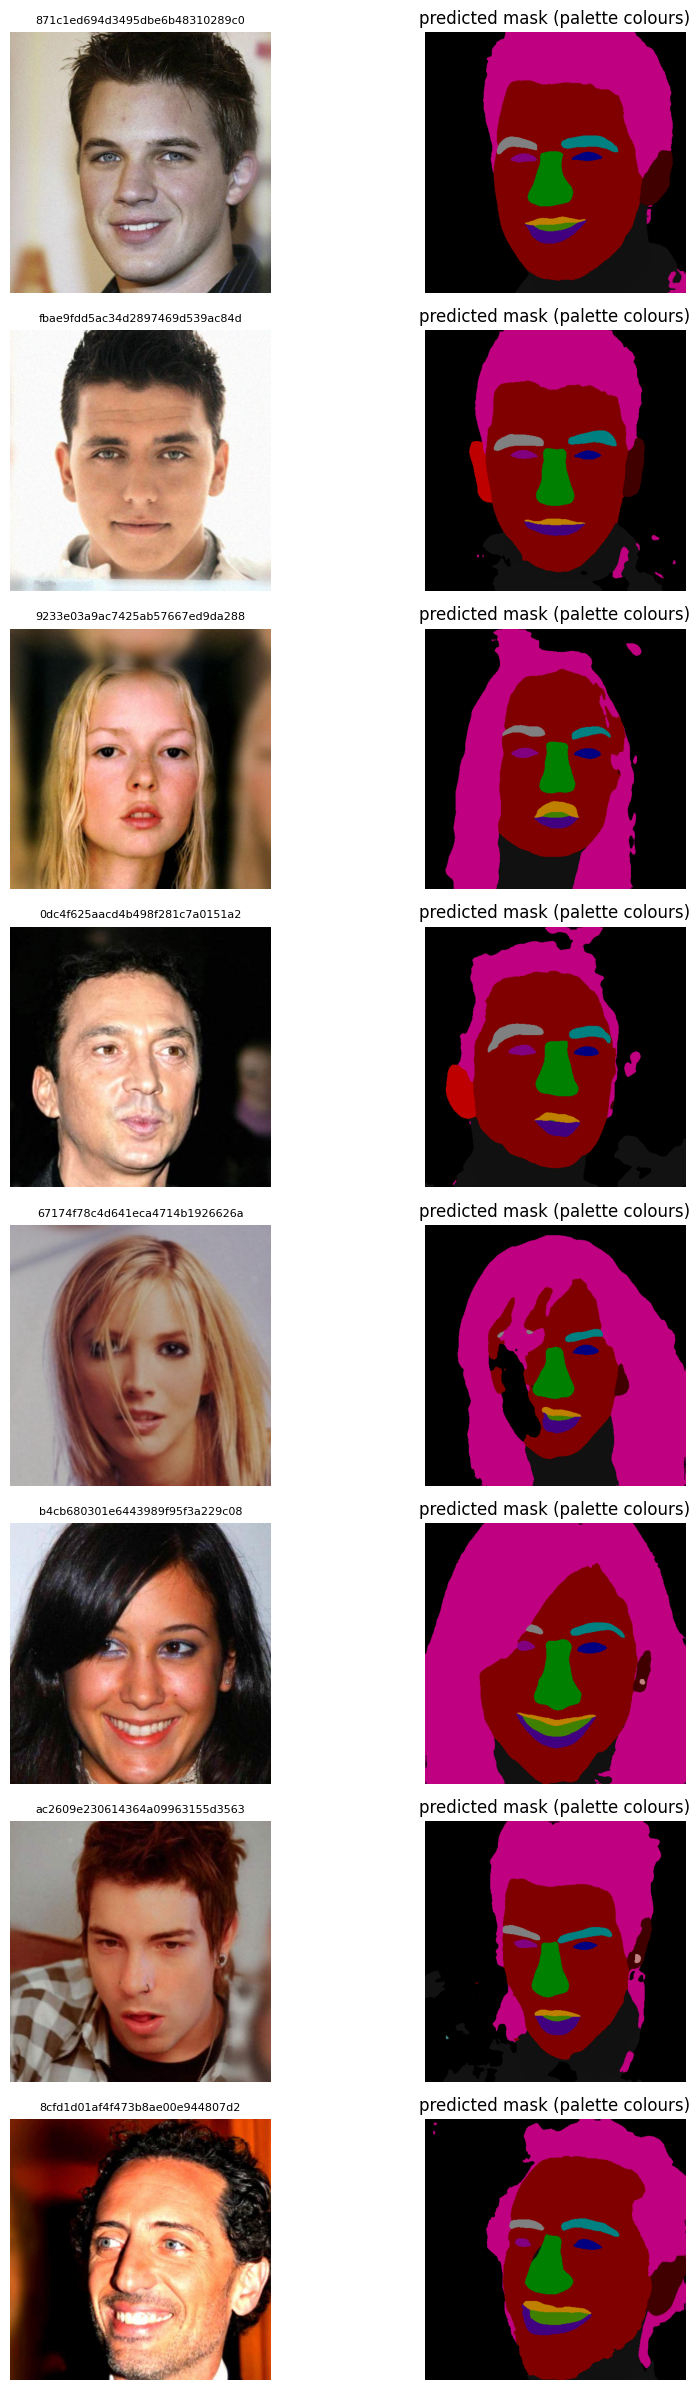

In [19]:
# --- visualise 8 random val samples (input image | palette-coloured prediction) ---
import random
random.seed(0)

n_show  = 8
indices = random.sample(range(len(val_ds)), n_show)
fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3))

for row, idx in enumerate(indices):
    img_tensor, fname = val_ds[idx]
    img_np    = img_tensor.permute(1, 2, 0).numpy()

    pred_path = os.path.join(out_dir, Path(fname).stem + ".png")
    # convert("RGB") applies the palette so matplotlib sees colours, not grey indices
    pred_rgb  = np.array(Image.open(pred_path).convert("RGB"))

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(Path(fname).name[:30], fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_rgb)
    axes[row, 1].set_title("predicted mask (palette colours)")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()